# Window-Level Anomaly Prediction from NASA Logs

This notebook uses **Part 1 feature extraction output directly** to build a window-level anomaly classification pipeline.

1. Load exported manual features from Part 1 (`artifacts/model_training/manual_features_full.csv`)
2. Validate and fix common schema issues if needed
3. Aggregate traffic into fixed 5-minute windows
4. Define anomalies by percentile threshold on error rate
5. Predict whether the **next** window is abnormal
6. Compare 4 model families: Logistic Regression, SVC, Random Forest, Gaussian Naive Bayes

Goal: reach at least 85% classification accuracy while comparing precision/recall/F1 trade-offs.

In [2]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

pd.set_option('display.max_columns', 80)
sns.set_theme(style='whitegrid')

In [16]:
project_root = Path('..').resolve()
candidate_feature_files = [
    project_root / 'artifacts' / 'model_training' / 'manual_features_full.csv',
    project_root / 'artifacts' / 'nasa_access_log_feature_sample.csv',
]

def is_lfs_pointer_csv(path: Path) -> bool:
    if not path.exists():
        return False
    first_line = path.open('r', errors='ignore').readline().strip()
    return first_line.startswith('version https://git-lfs.github.com/spec/v1')

selected_path = None
for candidate in candidate_feature_files:
    if candidate.exists() and not is_lfs_pointer_csv(candidate):
        selected_path = candidate
        break

if selected_path is None:
    raise FileNotFoundError(
        'No usable Part 1 feature output found. Ensure Part 1 export is generated and LFS files are pulled.'
    )

available_cols = pd.read_csv(selected_path, nrows=0).columns.tolist()
required_cols = ['datetime', 'host', 'endpoint']
optional_cols = ['status', 'bytes_filled', 'is_error', 'bytes']

missing_required = [c for c in required_cols if c not in available_cols]
if missing_required:
    raise ValueError(
        'Part 1 output format is missing required columns: ' + ', '.join(missing_required)
    )

usecols = [c for c in required_cols + optional_cols if c in available_cols]
df_features = pd.read_csv(selected_path, usecols=usecols)

# Format repairs for common Part 1 schema variants
df_features['datetime'] = pd.to_datetime(df_features['datetime'], errors='coerce')
if 'bytes_filled' not in df_features.columns and 'bytes' in df_features.columns:
    df_features['bytes_filled'] = pd.to_numeric(df_features['bytes'], errors='coerce').fillna(0)
if 'is_error' not in df_features.columns and 'status' in df_features.columns:
    status_numeric = pd.to_numeric(df_features['status'], errors='coerce')
    df_features['is_error'] = (status_numeric >= 400).astype(int)
if 'status' in df_features.columns:
    df_features['status'] = pd.to_numeric(df_features['status'], errors='coerce')

df_features['bytes_filled'] = pd.to_numeric(df_features.get('bytes_filled', 0), errors='coerce').fillna(0)
df_features['endpoint'] = df_features['endpoint'].fillna('')
df_features['host'] = df_features['host'].fillna('')

before_drop = len(df_features)
df_features = df_features.dropna(subset=['datetime']).copy()
after_drop = len(df_features)

print('Loaded Part 1 features from:', selected_path)
print('Rows loaded:', before_drop, '| Rows with valid datetime:', after_drop)
df_features.head()

Loaded Part 1 features from: /Users/sidqian/Downloads/Code/log-ml/artifacts/nasa_access_log_feature_sample.csv
Rows loaded: 1000 | Rows with valid datetime: 1000


,host,datetime,status,bytes,endpoint,is_error,bytes_filled
0,cbxguy.vip.best.com,1995-08-05 14:21:05-04:00,304.0,0.0,/elv/new01.gif,0,0.0
1,mjv.lib.uconn.edu,1995-07-06 13:34:03-04:00,200.0,543680.0,/shuttle/missions/sts-71/movies/sts-71-launch-...,0,543680.0
2,ix-cin3-03.ix.netcom.com,1995-07-08 07:08:58-04:00,304.0,0.0,/images/MOSAIC-logosmall.gif,0,0.0
3,n1028722.ksc.nasa.gov,1995-07-19 08:36:07-04:00,200.0,363.0,/images/MOSAIC-logosmall.gif,0,363.0
4,ix-knx-tn2-06.ix.netcom.com,1995-07-26 22:35:31-04:00,200.0,5866.0,/images/ksclogo-medium.gif,0,5866.0


In [17]:
required_for_windowing = ['datetime', 'host', 'endpoint', 'bytes_filled', 'is_error']
missing_for_windowing = [c for c in required_for_windowing if c not in df_features.columns]
if missing_for_windowing:
    raise ValueError(
        'Part 1 output is still missing required fields for Part 2: ' + ', '.join(missing_for_windowing)
    )

print('Part 2 is using Part 1 extracted features directly.')
print('Columns available for modeling pipeline:', sorted(df_features.columns.tolist()))
print('Error event rate in request-level data:', round(df_features['is_error'].mean(), 5))

df_features[['datetime', 'host', 'endpoint', 'bytes_filled', 'is_error']].head()

Part 2 is using Part 1 extracted features directly.
Columns available for modeling pipeline: ['bytes', 'bytes_filled', 'datetime', 'endpoint', 'host', 'is_error', 'status']
Error event rate in request-level data: 0.008


,datetime,host,endpoint,bytes_filled,is_error
0,1995-08-05 14:21:05-04:00,cbxguy.vip.best.com,/elv/new01.gif,0.0,0
1,1995-07-06 13:34:03-04:00,mjv.lib.uconn.edu,/shuttle/missions/sts-71/movies/sts-71-launch-...,543680.0,0
2,1995-07-08 07:08:58-04:00,ix-cin3-03.ix.netcom.com,/images/MOSAIC-logosmall.gif,0.0,0
3,1995-07-19 08:36:07-04:00,n1028722.ksc.nasa.gov,/images/MOSAIC-logosmall.gif,363.0,0
4,1995-07-26 22:35:31-04:00,ix-knx-tn2-06.ix.netcom.com,/images/ksclogo-medium.gif,5866.0,0


## Manual Features in 5-Minute Windows
We aggregate requests into fixed 5-minute frames and compute manual features used for classification.

In [18]:
window_features = (
    df_features
    .set_index('datetime')
    .sort_index()
    .resample('5min')
    .agg(
        request_count=('status', 'size'),
        unique_ips=('host', 'nunique'),
        error_count=('is_error', 'sum'),
        avg_response_size=('bytes_filled', 'mean'),
        p95_response_size=('bytes_filled', lambda x: x.quantile(0.95)),
        unique_endpoints=('endpoint', 'nunique'),
    )
    .reset_index()
)

window_features[['avg_response_size', 'p95_response_size']] = window_features[['avg_response_size', 'p95_response_size']].fillna(0)
window_features['error_rate'] = np.where(
    window_features['request_count'] > 0,
    window_features['error_count'] / window_features['request_count'],
    0
)

window_features.head()

,datetime,request_count,unique_ips,error_count,avg_response_size,p95_response_size,unique_endpoints,error_rate
0,1995-07-01 00:10:00-04:00,1,1,0,0.0,0.0,1,0.0
1,1995-07-01 00:15:00-04:00,0,0,0,0.0,0.0,0,0.0
2,1995-07-01 00:20:00-04:00,0,0,0,0.0,0.0,0,0.0
3,1995-07-01 00:25:00-04:00,0,0,0,0.0,0.0,0,0.0
4,1995-07-01 00:30:00-04:00,0,0,0,0.0,0.0,0,0.0


In [24]:
threshold_q = 0.95

# Use only windows with traffic for anomaly definition and supervised learning
active_windows = window_features.loc[window_features['request_count'] > 0].copy()

positive_error_rates = active_windows.loc[active_windows['error_rate'] > 0, 'error_rate']
if len(positive_error_rates) >= 20:
    error_threshold = positive_error_rates.quantile(threshold_q)
    active_windows['is_abnormal'] = (
        (active_windows['error_rate'] >= error_threshold) & (active_windows['error_rate'] > 0)
    ).astype(int)
    threshold_basis = 'error_rate'
else:
    # Fallback when error-rate signal is too sparse in sampled data
    error_threshold = active_windows['error_count'].quantile(threshold_q)
    active_windows['is_abnormal'] = (active_windows['error_count'] >= max(1, error_threshold)).astype(int)
    threshold_basis = 'error_count'

active_windows['target_next_window_abnormal'] = active_windows['is_abnormal'].shift(-1)

supervised_df = active_windows.dropna(subset=['target_next_window_abnormal']).copy()
supervised_df['target_next_window_abnormal'] = supervised_df['target_next_window_abnormal'].astype(int)

class_balance = supervised_df['target_next_window_abnormal'].value_counts().to_dict()
if len(class_balance) < 2:
    raise ValueError(
        'Target contains only one class after labeling. Re-run Part 1 export with more rows or adjust threshold_q.'
    )

print('Total 5-min windows:', len(window_features))
print('Active windows used:', len(active_windows))
print('Supervised rows:', len(supervised_df))
print(f'Anomaly threshold basis: {threshold_basis}, q={threshold_q}, value={round(float(error_threshold), 5)}')
print('Target class balance:', class_balance)
print('Positive rate of next-window abnormal:', round(supervised_df['target_next_window_abnormal'].mean(), 4))

supervised_df[['datetime', 'request_count', 'unique_ips', 'error_rate', 'is_abnormal', 'target_next_window_abnormal']].head()

Total 5-min windows: 17837
Active windows used: 957
Supervised rows: 956
Anomaly threshold basis: error_count, q=0.95, value=0.0
Target class balance: {0: 948, 1: 8}
Positive rate of next-window abnormal: 0.0084


,datetime,request_count,unique_ips,error_rate,is_abnormal,target_next_window_abnormal
0,1995-07-01 00:10:00-04:00,1,1,0.0,0,0
25,1995-07-01 02:15:00-04:00,1,1,0.0,0,0
33,1995-07-01 02:55:00-04:00,1,1,0.0,0,0
120,1995-07-01 10:10:00-04:00,1,1,0.0,0,0
131,1995-07-01 11:05:00-04:00,2,2,0.0,0,0


## Time-Based Train/Test Split and Model Training
We split by time order (first 80% train, last 20% test) and compare four model families.

In [25]:
feature_cols = [
    'request_count',
    'unique_ips',
    'error_count',
    'error_rate',
    'avg_response_size',
    'p95_response_size',
    'unique_endpoints',
]

X = supervised_df[feature_cols].copy()
y = supervised_df['target_next_window_abnormal'].copy()

split_idx = int(len(supervised_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print('Train rows:', len(X_train), '| Test rows:', len(X_test))
print('Train positive rate:', round(y_train.mean(), 4), '| Test positive rate:', round(y_test.mean(), 4))

Train rows: 764 | Test rows: 192
Train positive rate: 0.0105 | Test positive rate: 0.0


In [26]:
models = {
    'Logistic Regression': make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42)
    ),
    'Support Vector Classifier': make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf', class_weight='balanced', random_state=42)
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced_subsample',
        n_jobs=-1
    ),
    'Gaussian Naive Bayes': make_pipeline(
        StandardScaler(),
        GaussianNB()
    ),
}

results = []
predictions = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[model_name] = y_pred

    results.append({
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
    })

results_df = pd.DataFrame(results).sort_values(['accuracy', 'f1'], ascending=False).reset_index(drop=True)
results_df

,model,accuracy,precision,recall,f1
0,Random Forest,0.968750,0.0,0.0,0.0
1,Logistic Regression,0.307292,0.0,0.0,0.0
2,Support Vector Classifier,0.203125,0.0,0.0,0.0
3,Gaussian Naive Bayes,0.151042,0.0,0.0,0.0


Best model: Random Forest
Best accuracy: 0.9688
Target met (>= 0.85 accuracy): True


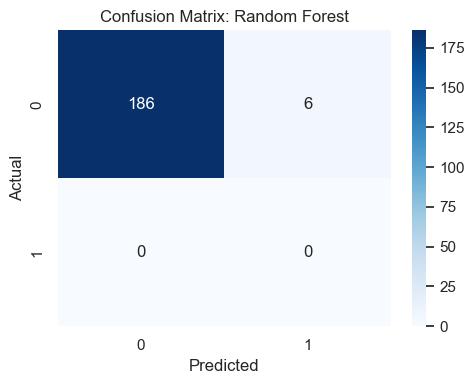

In [27]:
best_model_name = results_df.iloc[0]['model']
best_pred = predictions[best_model_name]
best_accuracy = results_df.iloc[0]['accuracy']

print('Best model:', best_model_name)
print('Best accuracy:', round(best_accuracy, 4))
print('Target met (>= 0.85 accuracy):', bool(best_accuracy >= 0.85))

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix: {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [28]:
artifacts_dir = project_root / 'artifacts' / 'window_level_models'
artifacts_dir.mkdir(parents=True, exist_ok=True)

window_features_path = artifacts_dir / 'window_features_5min.csv'
results_path = artifacts_dir / 'model_comparison_metrics.csv'

window_features.to_csv(window_features_path, index=False)
results_df.to_csv(results_path, index=False)

print('Saved window-level features to:', window_features_path)
print('Saved model metrics to:', results_path)

Saved window-level features to: /Users/sidqian/Downloads/Code/log-ml/artifacts/window_level_models/window_features_5min.csv
Saved model metrics to: /Users/sidqian/Downloads/Code/log-ml/artifacts/window_level_models/model_comparison_metrics.csv
